In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

GENERATIONS_DIR = os.path.join(os.path.dirname(os.getcwd()), "benchmark", "generations")
# If running from benchmark/ dir:
GENERATIONS_DIR = "generations"

In [2]:
def compute_pass_at_1(jsonl_path: str) -> float:
    """
    Compute pass@1 from a generations_results.jsonl file.
    Handles both single-line JSONL and pretty-printed (multi-line) JSON objects.
    pass@1 = # passed / # total tasks  (assumes one completion per task)
    """
    content = open(jsonl_path).read().strip()

    # Try to decode as a stream of concatenated JSON objects (handles both formats)
    records = []
    decoder = json.JSONDecoder()
    idx = 0
    while idx < len(content):
        # skip whitespace / newlines between objects
        while idx < len(content) and content[idx] in " \t\n\r":
            idx += 1
        if idx >= len(content):
            break
        obj, end = decoder.raw_decode(content, idx)
        records.append(obj)
        idx = end

    if not records:
        return float("nan")

    passed = sum(1 for r in records if r.get("passed", False))
    return passed / len(records)

In [3]:
# Model directory name  →  (display name, group, variant)
MODEL_META = {
    "starcoder2-3b":         ("StarCoder2-3B",  "StarCoder2-3B",  "base"),
    "StarCoder2Java-3b_ep3": ("SC2Java-3B ep3", "StarCoder2-3B",  "fine-tuned"),
    "starcoder2-7b":         ("StarCoder2-7B",  "StarCoder2-7B",  "base"),
    "StarCoder2Java-7b_ep3": ("SC2Java-7B ep3", "StarCoder2-7B",  "fine-tuned"),
    "starcoder2-15b":        ("StarCoder2-15B", "StarCoder2-15B", "base"),
    "StarCoder2Java-15b_ep3":("SC2Java-15B ep3","StarCoder2-15B", "fine-tuned"),
    "Mellum-4b-base":        ("Mellum-4B",      "Mellum-4B",      "base"),
    "MellumJava_ep3":        ("MellumJava ep3", "Mellum-4B",      "fine-tuned"),
}

rows = []
for folder, (display, group, variant) in MODEL_META.items():
    jsonl = os.path.join(GENERATIONS_DIR, folder, "generations_results.jsonl")
    p1 = compute_pass_at_1(jsonl)
    rows.append({"model": display, "group": group, "variant": variant, "pass@1": round(p1, 4)})

df_results = pd.DataFrame(rows)
df_results

,model,group,variant,pass@1
0,StarCoder2-3B,StarCoder2-3B,base,0.1220
1,SC2Java-3B ep3,StarCoder2-3B,fine-tuned,0.1890
2,StarCoder2-7B,StarCoder2-7B,base,0.1341
3,SC2Java-7B ep3,StarCoder2-7B,fine-tuned,0.1768
4,StarCoder2-15B,StarCoder2-15B,base,0.2378
5,SC2Java-15B ep3,StarCoder2-15B,fine-tuned,0.2744
6,Mellum-4B,Mellum-4B,base,0.1585
7,MellumJava ep3,Mellum-4B,fine-tuned,0.0122


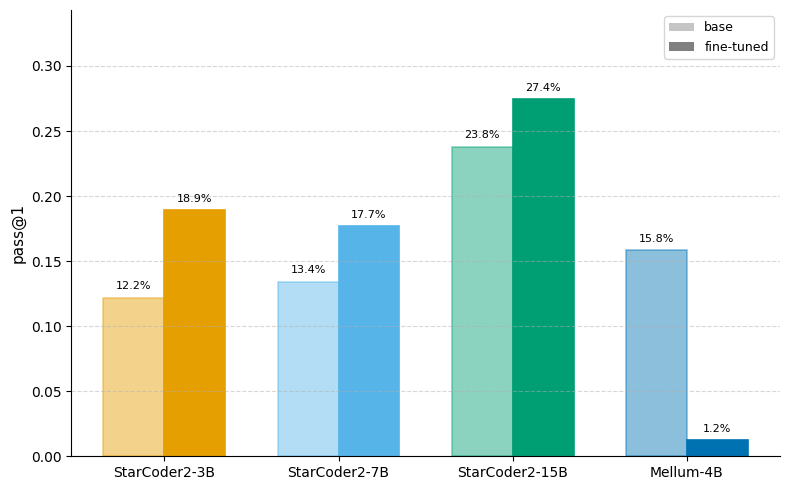

In [5]:
# --- Barplot: 4 groups × 2 bars (base / fine-tuned) ---
# Colors taken from the repo palette (cycler order)
GROUP_COLORS = {
    "StarCoder2-3B":  "#E69F00",
    "StarCoder2-7B":  "#56B4E9",
    "StarCoder2-15B": "#009E73",
    "Mellum-4B":      "#0072B2",
}
GROUPS = list(GROUP_COLORS.keys())

base_vals     = [df_results.query("group == @g and variant == 'base'")["pass@1"].values[0]       for g in GROUPS]
ft_vals       = [df_results.query("group == @g and variant == 'fine-tuned'")["pass@1"].values[0] for g in GROUPS]

x      = np.arange(len(GROUPS))
width  = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

for i, g in enumerate(GROUPS):
    color = GROUP_COLORS[g]
    # base bar: same color, lower alpha + hatch
    b1 = ax.bar(x[i] - width/2, base_vals[i],  width, color=color, alpha=0.45, edgecolor=color, linewidth=1.2)
    # fine-tuned bar: full color
    b2 = ax.bar(x[i] + width/2, ft_vals[i],    width, color=color, alpha=1.0,  edgecolor=color, linewidth=1.2)

    for bar in (b1, b2):
        h = bar[0].get_height()
        ax.text(bar[0].get_x() + bar[0].get_width() / 2, h + 0.005,
                f"{h:.1%}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(GROUPS, fontsize=10)
ax.set_ylabel("pass@1", fontsize=11)
ax.set_ylim(0, max(base_vals + ft_vals) * 1.25)
#ax.set_title("HumanEval-Java pass@1 — base vs fine-tuned", fontsize=12)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.5)

legend_patches = [
    Patch(facecolor="gray", alpha=0.45, label="base"),
    Patch(facecolor="gray", alpha=1.0,  label="fine-tuned"),
]
ax.legend(handles=legend_patches, frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig("pass_at_1_barplot.pdf", bbox_inches="tight")
plt.show()